# <div style = 'background-color:#50474E'> <center><font color='#F2DD6C'>Forecasting de series temporales sobre acciones de APPLE con ARIMA</div><div style = 'background-color:#50474E'> <center>.<font color='#50474E'></div>

El objetivo es aplicar un modelo ARIMA para predecir el precio de cierre de Apple (AAPL) y evaluar su desempeño en un contexto financiero real. En la práctica, los modelos ARIMA simples rara vez superan a un modelo ingenuo (persistencia: "El mejor pronóstico de mañana es el precio de hoy") en activos financieros, debido a la naturaleza impredecible de los mercados. El verdadero valor no está en el pronóstico, sino en entender por qué el modelo falla.


#### Indice

<div class="alert alert-block alert-info" style="margin-top: 20px">

1.  [Preparación y limpieza de los datos](#0)<br>
2.  [Arima](#1)<br>
3.  [Predicciones](#3) <br>
4.  [Conclusiones](#4) <br>

</div>

## <div style = 'background-color:#50474E'> <center><font color='white'>① Preparación y limpieza de los datos </font></div> <a id="0"></a>

In [1]:
import yfinance as yf # De donde saco los datos

import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore") #Filtrar avisos solo para limpieza visual de los resultados.

In [21]:
ticker = 'AAPL'
df = yf.download(ticker, start='2019-01-01', end='2026-05-01') # se descargan datos de los ultimos 7 años.

data = df['Close'] # Porque solo necesito el precio de cierre de la acción.
data = data.squeeze() # Para eliminar dimensiones innecesarias, porque librerías de series temporales (como auto_arima) esperan una Serie (1D) no un DataFrame (2D)
data.head(5)

[*********************100%***********************]  1 of 1 completed


Date
2019-01-02    37.503723
2019-01-03    33.768085
2019-01-04    35.209610
2019-01-07    35.131241
2019-01-08    35.800953
Name: AAPL, dtype: float64

In [3]:
data.tail(5) # Ver los ultimos 5 valores de los datos.

Date
2026-04-24    271.059998
2026-04-27    267.609985
2026-04-28    270.709991
2026-04-29    270.170013
2026-04-30    271.350006
Name: AAPL, dtype: float64

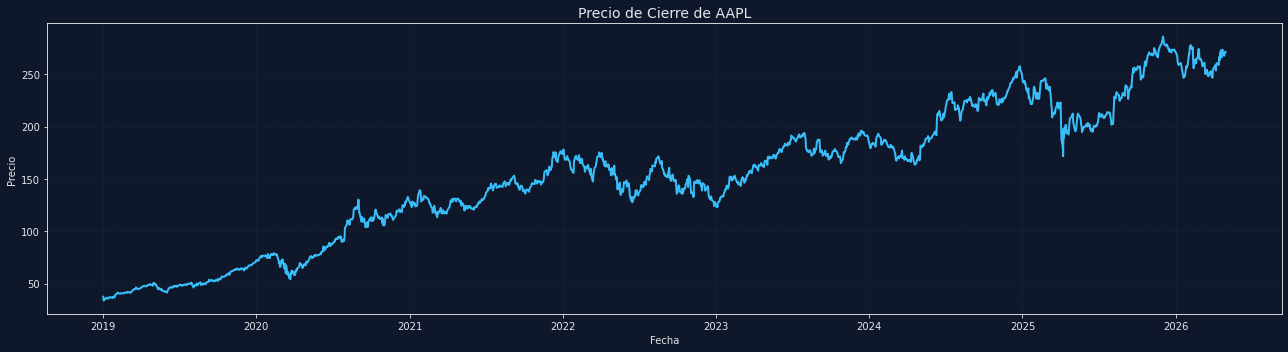

In [4]:
plt.style.use("dark_background") # Usar estilo oscuro para todos los graficos.

plt.figure(figsize=(18,5), facecolor="#0F172A")

plt.plot(data, color="#38BDF8", linewidth=2)

plt.title(f'Precio de Cierre de {ticker}', color="#E5E7EB", fontsize=14)
plt.xlabel("Fecha", color="#E5E7EB")
plt.ylabel("Precio", color="#E5E7EB")

plt.grid(color="#1E293B", linestyle="--", linewidth=0.5)

plt.gca().set_facecolor("#0F172A")

plt.tick_params(colors="#E5E7EB") # Color de los ticks en los ejes.

plt.tight_layout()
plt.show()

## <div style = 'background-color:black'> <center><font color='white'>② ARIMA </font></div><a id="1"></a>

**AR** (AutoRegresivo) : La variable se explica por sus propios valores pasados. Ejemplo: el precio de hoy depende del precio de ayer. **(-p-)**

**I** (Integrado) : Es la diferenciación que aplicamos para hacer la serie estacionaria. Corresponde al número de veces que diferenciamos los datos. **(-d-)**

**MA** (Media Móvil) : Modela el error del pronóstico como combinación de errores pasados. **(-q-)**

### Flujo de trabajo a seguir

| Paso | Acción | Criterio de decisión |
|------|--------|---------------------|
| 0 | Serie original | - |
| 1 | Test ADF | p-value < 0.05 → estacionaria |
| 2 | Definir d | Si no estacionaria → d = 1 |
| 3 | Ver ACF | Define q (MA) |
| 4 | Ver PACF | Define p (AR) |
| 5 | Entrenar ARIMA(p,d,q) | - |
| 6 | Predecir | - |

#### 1) Test de Dickey-Fuller Aumentado (ADF)

Las acciones no son estacionarias, lo que significa que su media y varianza cambian con el tiempo. Para aplicar un modelo ARIMA, es necesario que la serie sea estacionaria (comportamiento estable en el tiempo, sin tendencia marcada). Por ello, se utiliza el test de Dickey-Fuller, que permite evaluar esta propiedad.

Si el p-value obtenido es mayor a 0.05, no hay evidencia suficiente para rechazar la hipótesis de no estacionariedad, es decir, la serie no es estacionaria. En ese caso, es necesario transformarla, típicamente mediante diferenciación, hasta lograr que el p-value sea menor o igual a 0.05. Solo entonces se puede aplicar el modelo ARIMA.

In [5]:
def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Es estacionaria (Rechazamos H0)")
    else:
        print("No es estacionaria (No rechazamos H0)")

print("▪▪▪ Prueba para Serie Original ▪▪▪")
check_stationarity(data)

print("\n▪▪▪ Prueba para Serie Diferenciada (d=1) ▪▪▪")
data_diff = data.diff().dropna() # Se crea una nueva serie que contiene las variaciones (subidas y bajadas) de los datos originales.
check_stationarity(data_diff) # Se evalua esta nueva serie.

# Diff=Diferenciación, elimina tendencias y estacionalidad. Si los datos suben constantemente, ayuda a que la media se estabilice alrededor de 0. 
# Enfocandose en el cambio de un dia para otro en lugar del valor absoluto. 
# Dropna, como al aplicar diff el primer valor se convierte automaticamente en NAN (porque no tiene un dia anterior), con esto se limpia la serie.

▪▪▪ Prueba para Serie Original ▪▪▪
ADF Statistic: -0.9211330497377427
p-value: 0.7809333648491659
No es estacionaria (No rechazamos H0)

▪▪▪ Prueba para Serie Diferenciada (d=1) ▪▪▪
ADF Statistic: -42.270300982359885
p-value: 0.0
Es estacionaria (Rechazamos H0)


▪ Serie Original: El p-value de 0.67 es muy alto (muy por encima de 0.05). Normal en acciones como AAPL porque tienen tendencia, el precio de hoy depende mucho del de ayer.

▪ Serie Diferenciada: El p-value de 0.0. Significa que al restar el precio de ayer se elimina la tendencia y ahora es una serie con cambios diarios que oscila alrededor de una media constante.

Como se llego a una serie estacionaria con una sola vez que se plantean las diferencias, entonces d=1. Si no fuera asi, se plantea por segunda vez el test, si es estacionaria sera d=2.

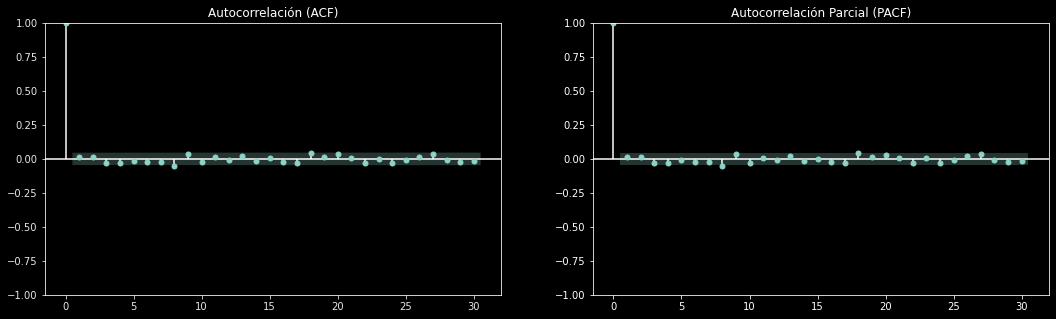

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5)) # Figura, dos plots en el mismo grafico.

# Gráfico ACF (para encontrar 'q')
plot_acf(data_diff, ax=ax1, lags=30)
ax1.set_title('Autocorrelación (ACF)')
ax1.tick_params(colors="#E5E7EB")

# Gráfico PACF (para encontrar 'p')
plot_pacf(data_diff, ax=ax2, lags=30)
ax2.set_title('Autocorrelación Parcial (PACF)')


plt.show()

En ambos gráficos no se observaron barras significativas por fuera de las bandas de confianza del 95%, más allá del lag 0. Esto indica que la serie diferenciada parece comportase como ruido blanco, es decir, no presenta dependencia serial significativa. En consecuencia, no es posible identificar órdenes "p" o "q" distintos de cero. Por lo tanto, el modelo más adecuado para esta serie es un ARIMA(0,1,0), también conocido como camino aleatorio o random walk y donde el mejor pronostico para el siguiente periodo es el valor actual.

In [7]:
# Separo datos para test y entrenamiento para poder evaluar si predice bien o mal.
train = data[:-30]
test = data[-30:]
model = ARIMA(train, order=(0, 1, 0))
model_fit = model.fit() # Entreno el modelo ARIMA.
pred = model_fit.forecast(steps=30)

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = np.mean(np.abs((test.values - pred.values) / test.values)) * 100
print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")

MAE: 11.00 | RMSE: 13.53 | MAPE: 4.13%


| Métrica | Valor | Observaciones |
|---------|-------|----------------|
| **MAE** | 11.00 | En promedio el error absoluto es de 11 unidades. Ej: si el precio real es 271, la predicción promedio fue 260 o 282. |
| **RMSE** | 13.53 | Penaliza errores grandes. Es un poco mayor que MAE (13.53 vs 11), lo que indica que hay algunos errores más grandes. |
| **MAPE** | 4.13% | El error porcentual promedio es del 4.13%. Ej: si el precio real es 271, la predicción promedio está entre 260 y 282. El error es bajo porque el random walk asume que el mejor pronóstico es el último valor conocido, lo cual es matemáticamente válido pero no implica que el modelo capture patrones reales del mercado. |

In [8]:
# Imprimir el resumen estadistico del modelo
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 1812
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -4458.030
Date:                Tue, 05 May 2026   AIC                           8918.060
Time:                        20:54:09   BIC                           8923.561
Sample:                             0   HQIC                          8920.090
                               - 1812                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         8.0478      0.120     67.052      0.000       7.813       8.283
Ljung-Box (L1) (Q):                   1.03   Jarque-Bera (JB):              4761.96
Prob(Q):                              0.31   Pr

| Test | Valor | p-value | ¿Qué significa? |
|------|-------|---------|------------------|
| **Ljung-Box (Q)** | 1.03 | 0.31 | p-value > 0.05 → Los residuos son **ruido blanco** (no hay autocorrelación). |
| **Jarque-Bera (JB)** | 4761.96 | 0.00 | p-value < 0.05 → Los residuos **NO son normales** (colas pesadas o picos pero común en finanzas) |
| **Skew (Asimetría)** | 0.09 | - | Cercano a 0 → distribución **simétrica** (sin sesgo significativo). |
| **Kurtosis (Curtosis)** | 10.94 | - | Mucho mayor que 3 (la normal tiene 3) → **colas pesadas**. Valor típico en precios de acciones. |
| **Heteroskedasticity (H)** | 3.40 | 0.00 | Hay **heterocedasticidad** (varianza no constante). Común en finanzas (volatilidad cambiante). |

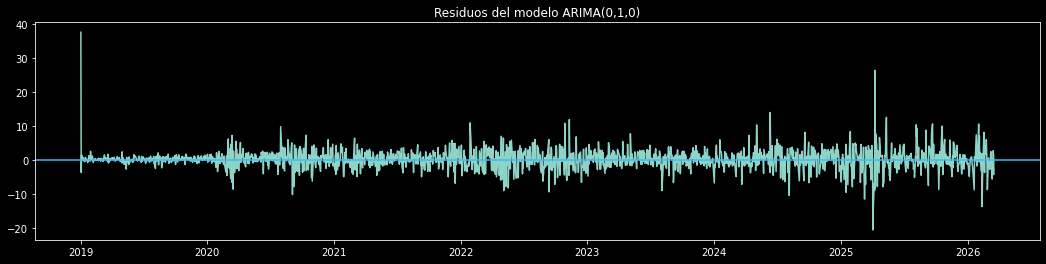

In [9]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

residuos = model_fit.resid # Defino la variable Residuos

plt.figure(figsize=(18,4))
plt.plot(residuos)
plt.axhline(y=0, color='#38BDF8', linestyle='-')
plt.title('Residuos del modelo ARIMA(0,1,0)')
plt.show()

Los residuos están centrados en cero, no tienen tendencia ni patrones. La mayoría son valores pequeños, con solo algunos picos aislados.

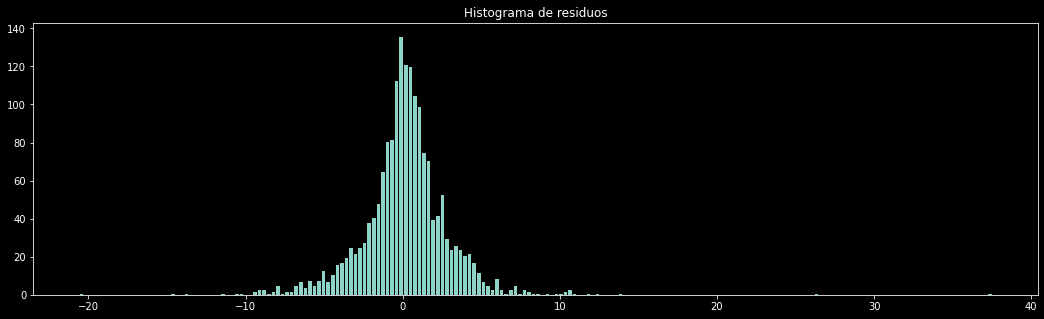

In [10]:
plt.figure(figsize=(18,5))
plt.hist(residuos, bins=200, edgecolor='black')
plt.title('Histograma de residuos')
plt.show()

El histograma de residuos presenta una forma que se aproxima a una distribución normal, evidenciando una clara simetría alrededor del valor central. Se observa una concentración mayor de residuos en las cercanías del cero, con una disminución gradual y progresiva hacia ambos extremos. Esta configuración en forma de campana sugiere que los errores del modelo siguen un comportamiento cercano al esperado bajo el supuesto de normalidad

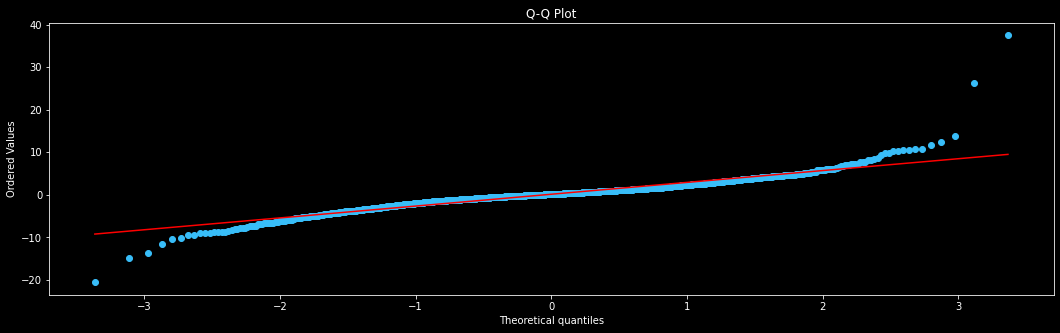

In [11]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(18, 5))

stats.probplot(model_fit.resid, dist="norm", plot=ax)

ax.get_lines()[0].set_color("#38BDF8") # Cambiar color de los puntos (datos)

ax.set_title("Q-Q Plot")
plt.show()

*Q-Q plot:* Este grafico compara la distribución de los datos con una distribución teórica (linea roja), se puede observar que en el centro sigue valores similares a esa linea. En los extremos se desvía bastante, son desvios frecuentes (colas pesadas o outliers) tal como lo indica el valor de Kurtosis de 10.94.

## <div style = 'background-color:black'> <center><font color='white'>③ Predicciones </font></div><a id="3"></a>

In [12]:
# Defino la variable predicciones, para predecir los próximos 30 períodos, los steps pueden ser D, M, A (Dias, Meses, Años)
predicciones = model_fit.forecast(steps=30)

In [13]:
print("Ejemplos de 7 predicciones:")
print(predicciones.head(7)) # Imprimir los 7 primeros precios predichos.

Ejemplos de 7 predicciones:
1812    249.940002
1813    249.940002
1814    249.940002
1815    249.940002
1816    249.940002
1817    249.940002
1818    249.940002
Name: predicted_mean, dtype: float64


In [14]:
# Codigo para crear fechas futuras (12 períodos después del último, cada periodo=dia)
ultima_fecha = data.index[-1]
fechas_futuras = pd.date_range(start=ultima_fecha + pd.DateOffset(1), periods=30, freq='B')  # o 'D' para días, 'Q' para trimestres, 'B' dias de oficina.

In [15]:
# Dado que se entrenó el modelo con valores reales pero que son 30 dias antes del final del listado, corro esto para que grafique teniendo en cuenta el ultimo dia real.

model_full = ARIMA(data, order=(0, 1, 0)).fit()
predicciones_full = model_full.forecast(steps=30)

ultima_fecha = data.index[-1]
fechas_futuras = pd.date_range(start=ultima_fecha + pd.DateOffset(1), periods=30, freq='B')

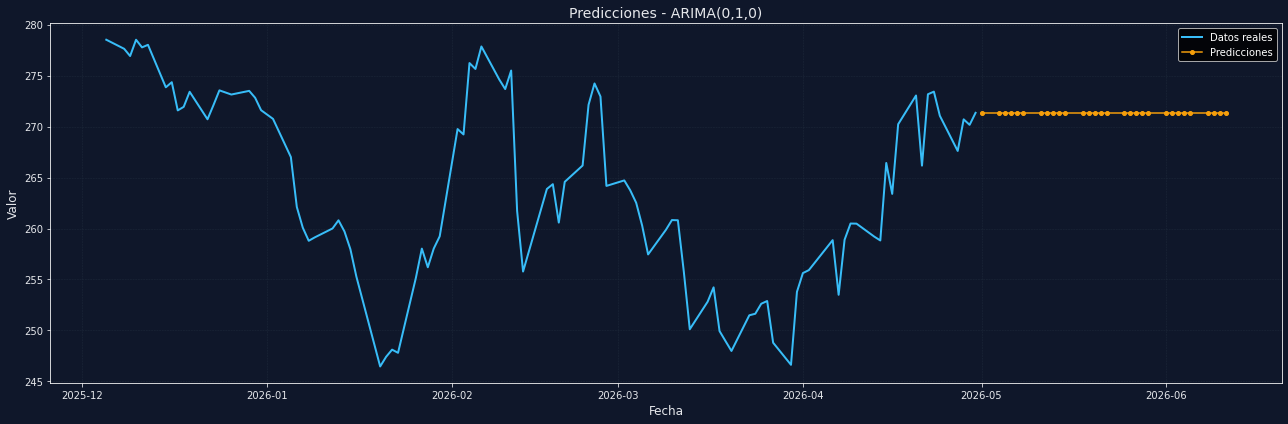

In [16]:
plt.style.use("dark_background")

plt.figure(figsize=(18, 6), facecolor="#0F172A")

data_filtrada = data.iloc[-100:] # Mostrar los ultimos 100 días

plt.plot(data_filtrada.index, data_filtrada.values, 
         label='Datos reales', color="#38BDF8", linewidth=2)

plt.plot(fechas_futuras[:30], predicciones_full[:30], 
         'o-', label='Predicciones', 
         color="#F59E0B", linewidth=1.5, markersize=4)

plt.title('Predicciones - ARIMA(0,1,0)', 
         color="#E5E7EB", fontsize=14)
plt.xlabel('Fecha', color="#E5E7EB", fontsize=12)
plt.ylabel('Valor', color="#E5E7EB", fontsize=12)

plt.gca().set_facecolor("#0F172A")
plt.tick_params(colors="#E5E7EB")
plt.grid(color="#1E293B", linestyle="--", linewidth=0.5)

plt.legend()
plt.tight_layout()
plt.show()


Esta es la predicción del modelo ARIMA(0,1,0) en su forma más simple. Dado que el término de error tiene media cero y no es predecible, la mejor estimación para cualquier período futuro es el último valor observado, que en este caso es 249.94 para el conjunto de datos de entrenamiento. Por lo tanto, el modelo proyecta ese mismo valor para todos los períodos siguientes, por razones de simplicidad y seguimiento muestro los valores de prediccion teniendo en cuenta todo el set de datos.

Si bien la predicción es estadísticamente consistente con esta especificación y el modelo fue correctamente entrenado, en la práctica toma el último valor real de la porción de datos de entrenamiento. Esto limita su utilidad para analizar o predecir el valor futuro de una acción, ya que es poco probable que un activo financiero mantenga el mismo precio durante varios períodos consecutivos. Esto se evidencia al comparar las predicciones con los valores reales del conjunto de test.

Por este motivo, se decidió avanzar hacia una especificación más flexible, utilizando auto_arima para que seleccione automáticamente los mejores parámetros.

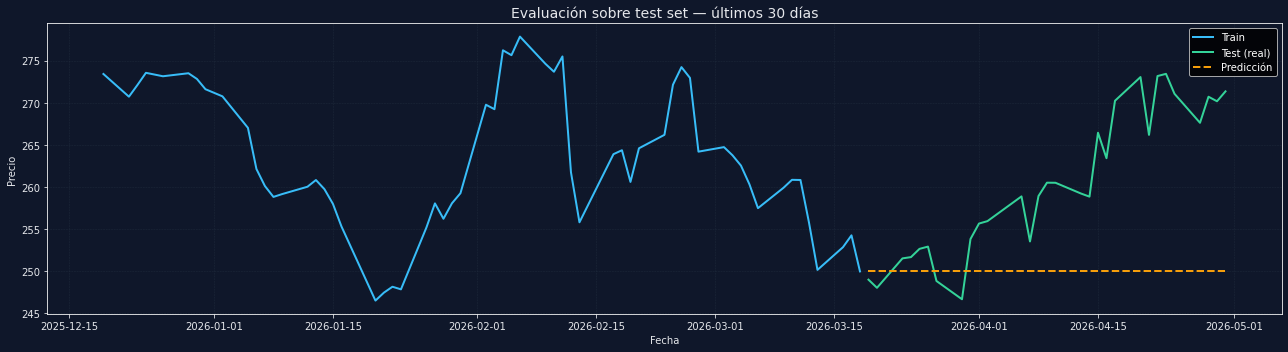

In [17]:
plt.figure(figsize=(18, 5), facecolor="#0F172A")
plt.style.use("dark_background")
plt.plot(train.index[-60:], train.values[-60:], color="#38BDF8", linewidth=2, label="Train")
plt.plot(test.index, test.values, color="#34D399", linewidth=2, label="Test (real)")
plt.plot(test.index, pred.values, color="#F59E0B", linewidth=2, linestyle="--", label="Predicción")
plt.title("Evaluación sobre test set — últimos 30 días", color="#E5E7EB", fontsize=14)
plt.xlabel("Fecha", color="#E5E7EB")
plt.ylabel("Precio", color="#E5E7EB")
plt.gca().set_facecolor("#0F172A")
plt.tick_params(colors="#E5E7EB")
plt.grid(color="#1E293B", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

En el siguiente gráfico se observa la serie segmentada en datos de entrenamiento (train), datos de prueba (test) y la predicción generada por el modelo ARIMA(0,1,0). Puede apreciarse que la predicción se mantiene en valores cercanos al último dato del conjunto de test y evoluciona de forma prácticamente constante, sin captar la dinámica observada en el conjunto de test. Esto evidencia la limitación del modelo para reflejar variaciones.

In [18]:
from pmdarima import auto_arima # Importo autoarima.

modelo_auto = auto_arima(
    data,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=False,
    trace=True
)

print(f"Modelo recomendado: ARIMA{modelo_auto.order}")

# Luego de definido los mejores parametros, predecir con ese modelo
predicciones = modelo_auto.predict(n_periods=36)
print(predicciones)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9084.806, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9086.414, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9086.423, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9086.459, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9088.785, Time=0.42 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.917 seconds
Modelo recomendado: ARIMA(0, 1, 0)
1842    271.477027
1843    271.604049
1844    271.731070
1845    271.858091
1846    271.985113
1847    272.112134
1848    272.239155
1849    272.366177
1850    272.493198
1851    272.620219
1852    272.747241
1853    272.874262
1854    273.001283
1855    273.128305
1856    273.255326
1857    273.382348
1858    273.509369
1859    273.636390
1860    273.763412
1861    273.890433
1862    274.017454
1863    274.144476
1864    274.271497
1865    274.398518
1866    274.525540
1867    274.652561
1868    274.779582
18

Auto_arima probó múltiples modelos y el mejor resultado fue nuevamente **ARIMA(0,1,0)**, coincidiendo con lo obtenido anteriormente.

Este modelo implica que la serie sigue un **camino aleatorio (random walk)**, pero esta vez con una **deriva positiva de aproximadamente +0.127 unidades por período**, sin dependencia significativa de valores ni errores pasados.

### Comparativa de modelos

| Modelo | Fórmula | Comportamiento |
|--------|---------|----------------|
| **Random walk puro** | `Y(t) = Y(t-1) + ε(t)` | Sube y baja sin dirección |
| **Random walk con deriva** | `Y(t) = Y(t-1) + c + ε(t)` | Tiende a subir de manera constante, pero con pasos impredecibles |

En términos más simples: la serie va subiendo muy de a poco pero de forma constante, aunque cada paso es impredecible.

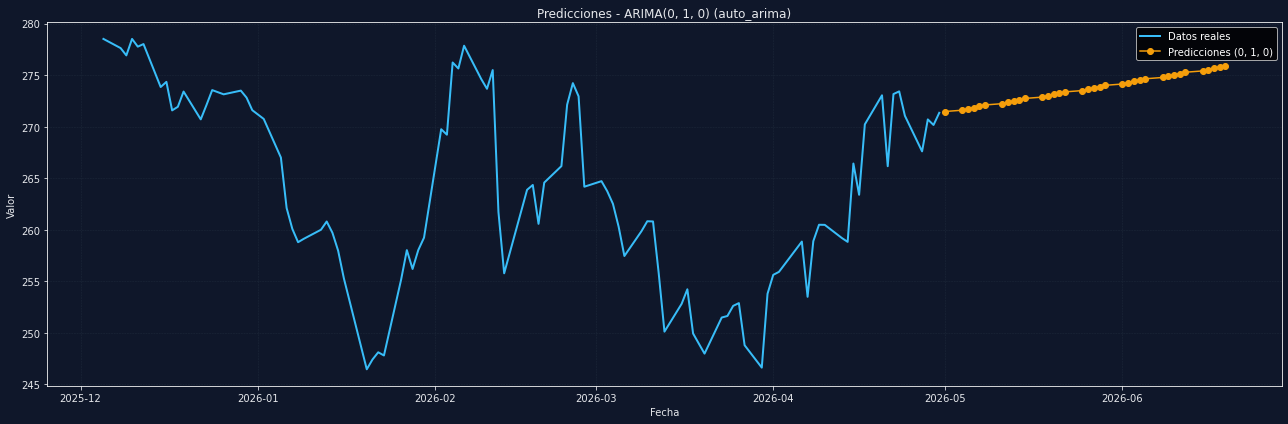

In [19]:
plt.style.use("dark_background")
plt.figure(figsize=(18, 6), facecolor="#0F172A")

# Últimos 100 días reales
plt.plot(data.index[-100:], data.values[-100:], 
         label='Datos reales', color="#38BDF8", linewidth=2)

if isinstance(data.index, pd.DatetimeIndex):
    ultima_fecha = data.index[-1]
    fechas_futuras = pd.date_range(start=ultima_fecha + pd.DateOffset(1), periods=36, freq='B') # Frequencias B (business days) en vez de diario (D).
    plt.plot(fechas_futuras, predicciones, 'o-', 
             label=f'Predicciones {modelo_auto.order}', color="#F59E0B", linewidth=1.5)
else:
    plt.plot(range(len(data), len(data)+36), predicciones, 'o-', 
             label=f'Predicciones {modelo_auto.order}', color="#F59E0B", linewidth=1.5)

plt.title(f'Predicciones - ARIMA{modelo_auto.order} (auto_arima)', color="#E5E7EB")
plt.xlabel('Fecha', color="#E5E7EB")
plt.ylabel('Valor', color="#E5E7EB")
plt.gca().set_facecolor("#0F172A")
plt.tick_params(colors="#E5E7EB")
plt.grid(color="#1E293B", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## <div style = 'background-color:black'> <center><font color='white'>④ Conclusiones </font></div><a id="4"></a>

El modelo ARIMA(0,1,0) con deriva genera predicciones que forman una línea recta, con pendiente constante igual al coeficiente de deriva. Esto es matemáticamente correcto según la estructura del modelo, pero implica que la serie no presenta patrones adicionales (estacionalidad, autocorrelación, etc.) que permitan enriquecer el pronóstico. Para activos financieros, esta simplificación puede resultar insuficiente, sugiriendo explorar SARIMA para estacionalidad, GARCH para volatilidad, o modelos de machine learning (Random Forest, XGBoost) para incorporar variables exógenas y relaciones no lineales.

In [20]:
# Probar distintas configuraciones de SARIMA.
model = auto_arima(data,
                   seasonal=True,
                   m=12,  # estacionalidad
                   trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=7.47 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=9084.806, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=9088.226, Time=0.42 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=9088.225, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=9086.459, Time=0.04 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=9086.636, Time=0.48 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=9086.626, Time=0.26 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=9088.263, Time=0.92 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=9086.414, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=9086.423, Time=0.16 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=9088.785, Time=0.31 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12] intercept
Total fit time: 10.695 seconds


Se implementaron modelos ARIMA y SARIMA sin obtener mejoras significativas en la capacidad predictiva, ningun modelo probado mejora al modelo mas simple, evidenciando que la serie presenta un comportamiento cercano a ruido o caminata aleatoria. En función de ello, se propone la utilización de modelos otros modelos.

---
✍️ Autor: Néstor Díaz — Contador Público | Analista de Datos | Machine Learning

📅 Proyecto: Análisis crediticio y gestión del riesgo de crédito

---